In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set visualization theme
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

# Load dataset
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [2]:
# Impute missing values using seasonal median values
impute_cols = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']
for col in impute_cols:
  df[col] = df.groupby('Season')[col].transform(
      lambda x: x.fillna(x.median())
  )

# Calculate financial indicators
df['ROI_pct'] = (
    (df['Revenue_INR'] - df['Total_Cost_INR']) / df['Total_Cost_INR']
) * 100
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR']) * 100
df['Cost_Per_Hectare'] = df['Total_Cost_INR'] / df['Farm_Area_Hectares']

print('Missing values clean check:')
print(df[impute_cols].isnull().sum())

Missing values clean check:
Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64


In [3]:
seasonal_summary = (
    df.groupby('Season')
    .agg(
        Record_Count=('Farm_ID', 'count'),
        Avg_Yield=('Yield_Tonnes_Ha', 'mean'),
        Avg_Rainfall=('Rainfall_mm', 'mean'),
        Avg_Temp=('Avg_Temperature_C', 'mean'),
        Avg_Humidity=('Humidity_pct', 'mean'),
        Avg_Water_Efficiency=('Water_Efficiency_t_per_1000m3', 'mean'),
        Avg_Disease_Risk=('Disease_Pest_Risk_pct', 'mean'),
        Avg_Profit=('Profit_INR', 'mean'),
    )
    .reset_index()
)

seasonal_summary

,Season,Record_Count,Avg_Yield,Avg_Rainfall,Avg_Temp,Avg_Humidity,Avg_Water_Efficiency,Avg_Disease_Risk,Avg_Profit
0,Kharif,1779,5.629438,852.112676,28.454019,71.812591,5.891834,54.467903,178914.647555
1,Rabi,1627,5.038451,435.937062,23.489183,57.893178,5.186122,40.482114,87689.470191
2,Zaid,594,4.638872,299.123232,31.042088,52.012121,4.413239,38.216667,-24804.824916


/tmp/ipykernel_1567/724765009.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=crop_fin, x='Crop', y='Avg_Profit', palette='vlag')


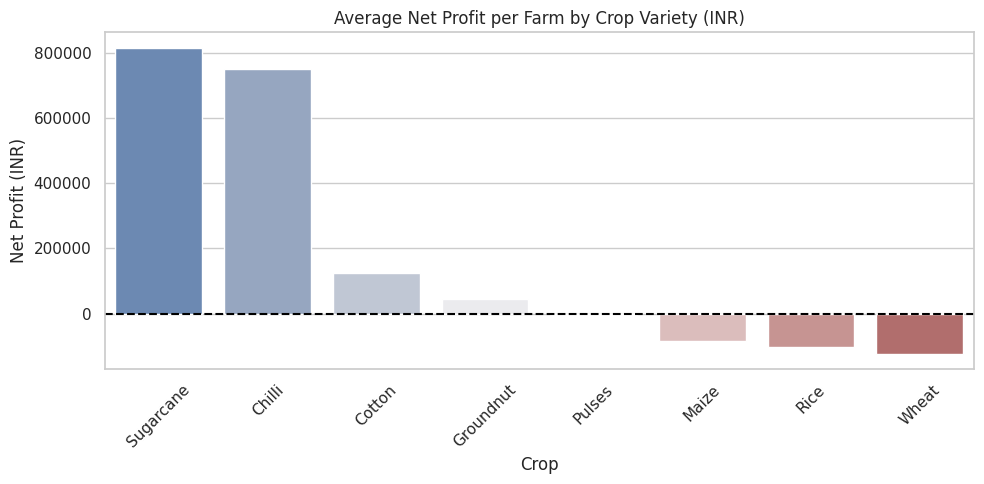

In [4]:
crop_fin = (
    df.groupby('Crop')
    .agg(
        Avg_Cost=('Total_Cost_INR', 'mean'),
        Avg_Revenue=('Revenue_INR', 'mean'),
        Avg_Profit=('Profit_INR', 'mean'),
        Avg_ROI=('ROI_pct', 'mean'),
    )
    .reset_index()
    .sort_values(by='Avg_Profit', ascending=False)
)

# Plotting
plt.figure(figsize=(10, 5))
sns.barplot(data=crop_fin, x='Crop', y='Avg_Profit', palette='vlag')
plt.axhline(0, color='black', linestyle='--')
plt.title('Average Net Profit per Farm by Crop Variety (INR)', fontsize=12)
plt.ylabel('Net Profit (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()